**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 17 - Manejo de datos estructurados. Preprocesado, análisis y visualización**

## Complemento

Este notebook se complementa con la presentación: **schwabish-2014-an-economist-s-guide-to-visualizing-data.pdf**

Te recomendamos leer el PDF para trabajar con este notebook y tener una mejor comprensión de los conceptos teóricos.

## ¿Qué vamos a hacer en esta clase?

Vamos a trabajar con **dos datasets reales**:

- 🎵 **Spotify Top Songs** — canciones con variables de audio y popularidad
- ⚽ **Premier League 2023/24** — resultados partido a partido

Para cada dataset aplicamos el pipeline completo:
1. **Exploración** — entender la estructura del dataset
2. **Preprocesado** — limpiar y transformar
3. **Análisis** — agrupar y resumir
4. **Visualización** — graficar con `seaborn` y `matplotlib` siguiendo los principios de Schwabish (2014)

Al final, incorporamos un **agente de análisis** basado en la API de Claude que responde preguntas sobre los datos en lenguaje natural.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo base de seaborn: grilla blanca sin bordes superiores/derechos
sns.set_theme(style="whitegrid", palette="muted")

pd.set_option("display.float_format", "{:,.2f}".format)

---
# 🎵 Parte A — Spotify Top Songs

## A1. Carga y exploración

El dataset contiene canciones de las playlists de Spotify con variables de audio como energía, bailabilidad, tempo y popularidad.

### Documentación y descarga

| | |
|---|---|
| **Descarga directa** | [spotify_songs.csv](https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv) |
| **Documentación completa** | [TidyTuesday — Spotify Songs (2020-01-21)](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-01-21/readme.md) |
| **Fuente original** | Spotify Web API vía el paquete `spotifyr` de R |

**Variables principales:**

| Variable | Descripción |
|---|---|
| `track_popularity` | Popularidad de 0 a 100 (calculada por Spotify según reproducciones recientes) |
| `playlist_genre` | Género de la playlist: `pop`, `rap`, `rock`, `latin`, `r&b`, `edm` |
| `danceability` | Qué tan apta es la canción para bailar (0–1) |
| `energy` | Intensidad y actividad percibida (0–1) |
| `valence` | Positividad musical: valores altos = alegre, bajos = triste (0–1) |
| `tempo` | Tempo estimado en BPM |
| `loudness` | Volumen promedio en decibeles (dB) |
| `duration_ms` | Duración de la canción en milisegundos |

In [60]:
url_spotify = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
sp = pd.read_csv(url_spotify)
print("Dimensiones:", sp.shape)
sp.head()

Dimensiones: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.63,1,0.06,0.10,0.00,0.07,0.52,122.04,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.97,1,0.04,0.07,0.00,0.36,0.69,99.97,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.43,0,0.07,0.08,0.00,0.11,0.61,124.01,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.78,1,0.10,0.03,0.00,0.20,0.28,121.96,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.67,1,0.04,0.08,0.00,0.08,0.72,123.98,189052


In [61]:
sp.dtypes

track_id                     object
track_name                   object
track_artist                 object
track_popularity              int64
track_album_id               object
track_album_name             object
track_album_release_date     object
playlist_name                object
playlist_id                  object
playlist_genre               object
playlist_subgenre            object
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

In [62]:
# Variables numéricas relevantes
sp[['track_popularity', 'danceability', 'energy', 'valence', 'tempo', 'loudness']].describe().round(2)

,track_popularity,danceability,energy,valence,tempo,loudness
count,"32,833.00","32,833.00","32,833.00","32,833.00","32,833.00","32,833.00"
mean,42.48,0.65,0.70,0.51,120.88,-6.72
std,24.98,0.15,0.18,0.23,26.90,2.99
min,0.00,0.00,0.00,0.00,0.00,-46.45
25%,24.00,0.56,0.58,0.33,99.96,-8.17
50%,45.00,0.67,0.72,0.51,121.98,-6.17
75%,62.00,0.76,0.84,0.69,133.92,-4.64
max,100.00,0.98,1.00,0.99,239.44,1.27


## A2. Preprocesado

In [63]:
# Valores nulos
print("Nulos por columna:")
print(sp.isnull().sum()[sp.isnull().sum() > 0])

Nulos por columna:
track_name          5
track_artist        5
track_album_name    5
dtype: int64


In [64]:
# Eliminar duplicados (misma canción en varias playlists)
sp_unique = sp.drop_duplicates(subset="track_id").reset_index(drop=True)
print(f"Filas originales:  {len(sp):,}")
print(f"Sin duplicados:    {len(sp_unique):,}")

Filas originales:  32,833
Sin duplicados:    28,356


In [65]:
# Quedarnos con las columnas útiles y renombrar
cols = ["track_name", "track_artist", "track_popularity",
        "playlist_genre", "danceability", "energy",
        "valence", "tempo", "loudness", "duration_ms"]
sp = sp_unique[cols].copy()
sp = sp.rename(columns={"playlist_genre": "genero",
                         "track_popularity": "popularidad",
                         "track_artist": "artista",
                         "track_name": "cancion"})

# Convertir duración a minutos
sp["duracion_min"] = (sp["duration_ms"] / 60_000).round(2)
sp = sp.drop(columns="duration_ms")
sp.head()

,cancion,artista,popularidad,genero,danceability,energy,valence,tempo,loudness,duracion_min
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,pop,0.75,0.92,0.52,122.04,-2.63,3.25
1,Memories - Dillon Francis Remix,Maroon 5,67,pop,0.73,0.81,0.69,99.97,-4.97,2.71
2,All the Time - Don Diablo Remix,Zara Larsson,70,pop,0.68,0.93,0.61,124.01,-3.43,2.94
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,pop,0.72,0.93,0.28,121.96,-3.78,2.82
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,pop,0.65,0.83,0.72,123.98,-4.67,3.15


## A3. Análisis

In [66]:
# Popularidad promedio por género
pop_genero = sp.groupby("genero")["popularidad"].mean().sort_values(ascending=False).round(1)
pop_genero

genero
pop     45.90
rap     41.80
latin   41.40
rock    39.70
r&b     35.90
edm     30.70
Name: popularidad, dtype: float64

In [67]:
# Top 10 canciones más populares
sp.nlargest(10, "popularidad")[["cancion", "artista", "genero", "popularidad"]]

,cancion,artista,genero,popularidad
1504,Dance Monkey,Tones and I,pop,100
18031,ROXANNE,Arizona Zervas,latin,99
687,Tusa,KAROL G,pop,98
711,Memories,Maroon 5,pop,98
716,Blinding Lights,The Weeknd,pop,98
1299,Circles,Post Malone,pop,98
5133,The Box,Roddy Ricch,rap,98
689,everything i wanted,Billie Eilish,pop,97
1300,Don't Start Now,Dua Lipa,pop,97
2941,Falling,Trevor Daniel,pop,97


In [68]:
# Correlación entre variables de audio
vars_audio = ["popularidad", "danceability", "energy", "valence", "tempo", "loudness"]
sp[vars_audio].corr().round(2)

,popularidad,danceability,energy,valence,tempo,loudness
popularidad,1.00,0.05,-0.10,0.02,0.00,0.04
danceability,0.05,1.00,-0.08,0.33,-0.18,0.02
energy,-0.10,-0.08,1.00,0.15,0.15,0.68
valence,0.02,0.33,0.15,1.00,-0.03,0.05
tempo,0.00,-0.18,0.15,-0.03,1.00,0.10
loudness,0.04,0.02,0.68,0.05,0.10,1.00


## A4. Visualización con Seaborn

> **Principios de Schwabish aplicados:**
> - Grillas tenues (`whitegrid`) en lugar de grillas pesadas
> - Sin bordes superiores ni derechos (`despine`)
> - Paletas de color semánticas, no decorativas

C:\Users\juanc\AppData\Local\Temp\ipykernel_18156\3595188095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sp, x="genero", y="popularidad",


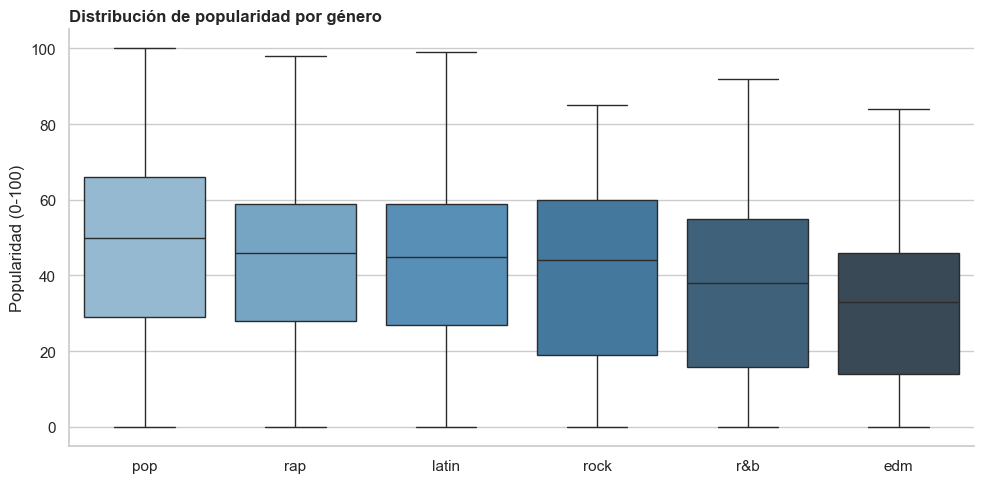

In [69]:
# Distribución de popularidad por género (boxplot)
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sp, x="genero", y="popularidad",
            palette="Blues_d", order=pop_genero.index, ax=ax)
ax.set_title("Distribución de popularidad por género", loc="left", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Popularidad (0-100)")
sns.despine()
plt.tight_layout()
plt.show()

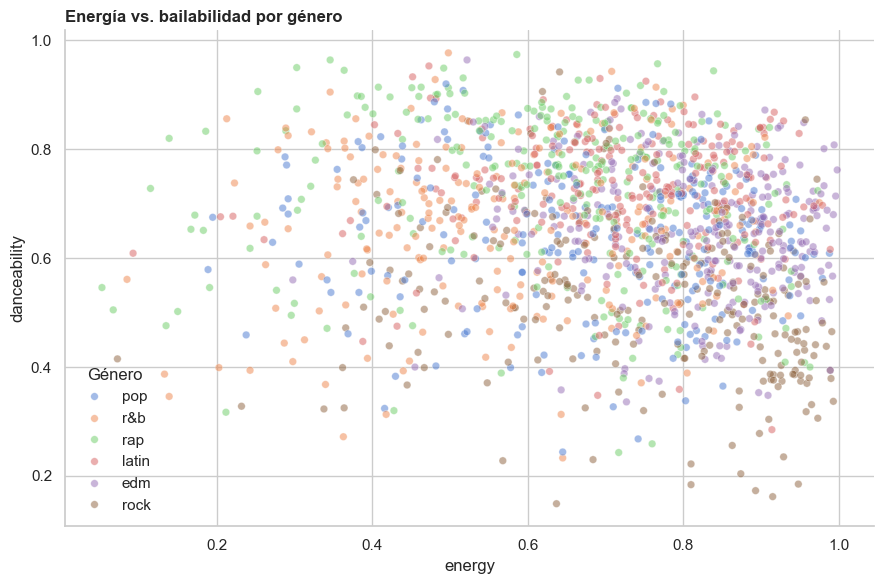

In [70]:
# Relación energía vs. bailabilidad, coloreado por género
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=sp.sample(1500, random_state=42),
                x="energy", y="danceability",
                hue="genero", alpha=0.5, s=30, ax=ax)
ax.set_title("Energía vs. bailabilidad por género", loc="left", fontweight="bold")
ax.legend(frameon=False, title="Género")
sns.despine()
plt.tight_layout()
plt.show()

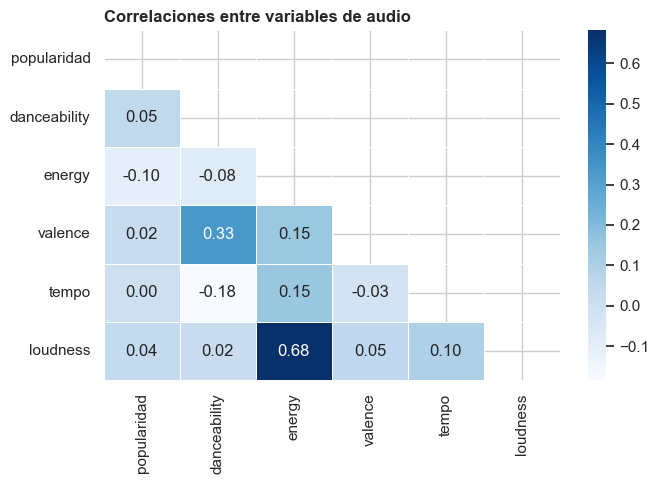

In [71]:
# Mapa de calor de correlaciones
fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(sp[vars_audio].corr(), dtype=bool))
sns.heatmap(sp[vars_audio].corr(), mask=mask, annot=True, fmt=".2f",
            cmap="Blues", linewidths=0.5, ax=ax)
ax.set_title("Correlaciones entre variables de audio", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\juanc\AppData\Local\Temp\ipykernel_18156\472890715.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pop_genero.values, y=pop_genero.index,


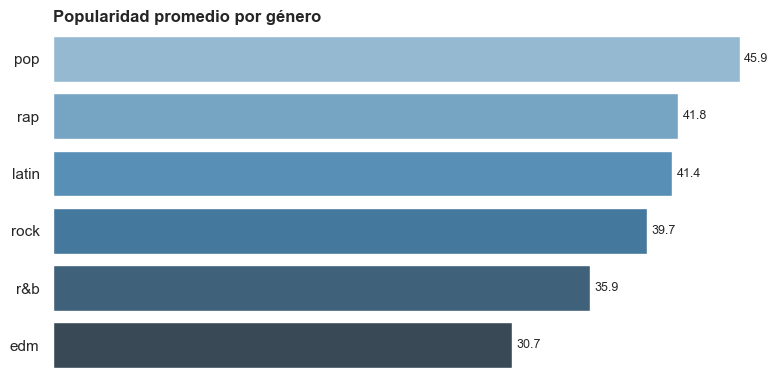

In [72]:
# Popularidad promedio por género (barplot horizontal)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=pop_genero.values, y=pop_genero.index,
            palette="Blues_d", ax=ax)
ax.set_title("Popularidad promedio por género", loc="left", fontweight="bold")
ax.set_xlabel("Popularidad promedio")
ax.set_ylabel("")
for bar, val in zip(ax.patches, pop_genero.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=9)
sns.despine(left=True, bottom=True)
ax.xaxis.set_visible(False)
plt.tight_layout()
plt.show()

## A5. Regresión lineal simple

¿Pueden los atributos de audio predecir la popularidad de una canción?

Vamos a ajustar una regresión lineal simple: usamos `energy` como variable predictora y `popularidad` como variable a explicar.

$$\text{popularidad} = \beta_0 + \beta_1 \cdot \text{energy} + \varepsilon$$

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Variable predictora y variable objetivo
X = sp[["energy"]].values
y = sp["popularidad"].values

# Ajustar el modelo
modelo_sp = LinearRegression()
modelo_sp.fit(X, y)

# Resultados
print(f"Intercepto (β₀):  {modelo_sp.intercept_:.2f}")
print(f"Coeficiente (β₁): {modelo_sp.coef_[0]:.2f}")
print(f"R²:               {r2_score(y, modelo_sp.predict(X)):.4f}")

Intercepto (β₀):  48.68
Coeficiente (β₁): -13.38
R²:               0.0107


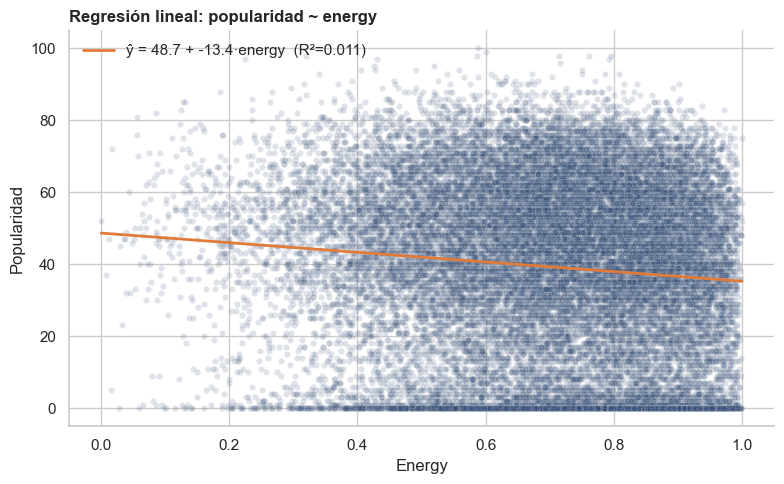

In [74]:
# Visualización: scatter + línea de regresión
x_rango = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred  = modelo_sp.predict(x_rango)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=sp["energy"], y=sp["popularidad"],
                alpha=0.15, color="#2c4770", s=20, ax=ax)
ax.plot(x_rango, y_pred, color="#e07b39", linewidth=2,
        label=f"ŷ = {modelo_sp.intercept_:.1f} + {modelo_sp.coef_[0]:.1f}·energy  (R²={r2_score(y, modelo_sp.predict(X)):.3f})")

ax.set_title("Regresión lineal: popularidad ~ energy", loc="left", fontweight="bold")
ax.set_xlabel("Energy")
ax.set_ylabel("Popularidad")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### Tests de significatividad

Para evaluar si la relación encontrada es **estadísticamente significativa** usamos dos tests:

- **Test t** (por coeficiente): contrasta $H_0: \beta_j = 0$. Si el p-valor < 0.05, el coeficiente es significativo.
- **Test F** (global): contrasta $H_0: \text{todos los } \beta_j = 0$. Evalúa si el modelo en su conjunto tiene poder explicativo.

Usamos `statsmodels` que devuelve el resumen completo de la regresión OLS.

In [75]:
import statsmodels.api as sm

# Agregar constante (intercepto) al modelo
X_sm = sm.add_constant(sp["energy"])

# Ajustar OLS
ols_sp = sm.OLS(sp["popularidad"], X_sm).fit()

# Resumen completo
print(ols_sp.summary())

                            OLS Regression Results                            
Dep. Variable:            popularidad   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     307.8
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           1.55e-68
Time:                        22:24:47   Log-Likelihood:            -1.2984e+05
No. Observations:               28356   AIC:                         2.597e+05
Df Residuals:                   28354   BIC:                         2.597e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.6773      0.551     88.356      0.0

**¿Cómo leer el output?**

| Sección | Qué mirar | Interpretación |
|---|---|---|
| **Test F** | `F-statistic` y `Prob (F-statistic)` | Si p < 0.05, el modelo es globalmente significativo |
| **Test t — constante** | `t` y `P>\|t\|` de la fila `const` | Significatividad del intercepto β₀ |
| **Test t — energy** | `t` y `P>\|t\|` de la fila `energy` | Significatividad de β₁: ¿energy predice popularidad? |
| **R²** | `R-squared` | Proporción de varianza de popularidad explicada por energy |
| **Coef** | Columna `coef` | Valor estimado de cada β |

---
## ¿Y después de explorar y visualizar? → Machine Learning predictivo

Con un dataset como este, el análisis descriptivo es solo el punto de partida. El siguiente paso natural es construir **modelos predictivos** que aprendan patrones en los datos para hacer predicciones sobre observaciones nuevas.

Algunos modelos que veremos más adelante:

| Modelo | ¿Para qué sirve en este dataset? |
|---|---|
| **Regresión lineal / Ridge / Lasso** | Predecir la `popularidad` de una canción a partir de sus atributos de audio |
| **Árbol de decisión** | Clasificar el `genero` de una canción según energía, tempo y bailabilidad |
| **Random Forest** | Mejorar la clasificación combinando cientos de árboles; también sirve para rankear qué variables son más importantes |
| **Gradient Boosting (XGBoost)** | Modelo de alta performance para clasificación y regresión; suele ganar competencias de datos |
| **K-Means Clustering** | Agrupar canciones similares sin etiquetas previas; útil para descubrir géneros "naturales" en los datos |

🔔 Todos estos modelos arrancan exactamente del DataFrame limpio y procesado que construimos en esta clase.

---
# ⚽ Parte B — Premier League 2023/24

## B1. Carga y exploración

El dataset contiene todos los partidos de la Premier League 2023/24 con goles, tiros, tarjetas y más.

### Documentación y descarga

| | |
|---|---|
| **Descarga directa** | [E0.csv — Premier League 2023/24](https://www.football-data.co.uk/mmz4281/2324/E0.csv) |
| **Documentación completa** | [football-data.co.uk — Notas de columnas](https://www.football-data.co.uk/notes.txt) |
| **Fuente** | [football-data.co.uk](https://www.football-data.co.uk/) — datos históricos de ligas europeas |

**Variables principales (post-renombre):**

| Variable original | Variable renombrada | Descripción |
|---|---|---|
| `HomeTeam` / `AwayTeam` | `local` / `visitante` | Equipos del partido |
| `FTHG` / `FTAG` | `goles_local` / `goles_visitante` | Goles al final del partido (Full Time) |
| `FTR` | `resultado` | Resultado: `H` (local), `A` (visitante), `D` (empate) |
| `HS` / `AS` | `tiros_local` / `tiros_visitante` | Total de tiros |
| `HST` / `AST` | `al_arco_local` / `al_arco_visitante` | Tiros al arco |
| `HY` / `AY` | `amarillas_local` / `amarillas_visitante` | Tarjetas amarillas |
| `HR` / `AR` | `rojas_local` / `rojas_visitante` | Tarjetas rojas |

> El dataset original tiene 106 columnas — la mayoría son cuotas de apuestas de distintas casas.

In [76]:
url_pl = "https://www.football-data.co.uk/mmz4281/2324/E0.csv"
pl = pd.read_csv(url_pl)
print("Dimensiones:", pl.shape)
pl.head()

Dimensiones: (380, 106)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88


In [77]:
# Columnas disponibles
print(pl.columns.tolist())

['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA']


## B2. Preprocesado

In [78]:
# Seleccionamos las columnas de interés
cols_pl = ["Date", "HomeTeam", "AwayTeam",
           "FTHG", "FTAG", "FTR",
           "HS", "AS", "HST", "AST",
           "HY", "AY", "HR", "AR"]
pl = pl[cols_pl].copy()

pl = pl.rename(columns={
    "HomeTeam": "local", "AwayTeam": "visitante",
    "FTHG": "goles_local", "FTAG": "goles_visitante", "FTR": "resultado",
    "HS": "tiros_local", "AS": "tiros_visitante",
    "HST": "al_arco_local", "AST": "al_arco_visitante",
    "HY": "amarillas_local", "AY": "amarillas_visitante",
    "HR": "rojas_local", "AR": "rojas_visitante"
})

pl["Date"] = pd.to_datetime(pl["Date"], dayfirst=True)
pl["goles_total"] = pl["goles_local"] + pl["goles_visitante"]
pl.head()

,Date,local,visitante,goles_local,goles_visitante,resultado,tiros_local,tiros_visitante,al_arco_local,al_arco_visitante,amarillas_local,amarillas_visitante,rojas_local,rojas_visitante,goles_total
0,2023-08-11,Burnley,Man City,0,3,A,6,17,1,8,0,0,1,0,3
1,2023-08-12,Arsenal,Nott'm Forest,2,1,H,15,6,7,2,2,2,0,0,3
2,2023-08-12,Bournemouth,West Ham,1,1,D,14,16,5,3,1,4,0,0,2
3,2023-08-12,Brighton,Luton,4,1,H,27,9,12,3,2,2,0,0,5
4,2023-08-12,Everton,Fulham,0,1,A,19,9,9,2,0,2,0,0,1


In [79]:
print("Nulos:")
print(pl.isnull().sum()[pl.isnull().sum() > 0])

Nulos:
Series([], dtype: int64)


## B3. Análisis — Tabla de posiciones

In [80]:
# Construimos la tabla de posiciones manualmente
equipos = pd.unique(pl[["local", "visitante"]].values.ravel())

tabla = []
for equipo in equipos:
    partidos_local    = pl[pl["local"] == equipo]
    partidos_visitante = pl[pl["visitante"] == equipo]

    pj = len(partidos_local) + len(partidos_visitante)
    pg = (partidos_local["resultado"] == "H").sum() + (partidos_visitante["resultado"] == "A").sum()
    pe = (partidos_local["resultado"] == "D").sum() + (partidos_visitante["resultado"] == "D").sum()
    pp = pj - pg - pe
    gf = partidos_local["goles_local"].sum() + partidos_visitante["goles_visitante"].sum()
    gc = partidos_local["goles_visitante"].sum() + partidos_visitante["goles_local"].sum()
    pts = pg * 3 + pe

    tabla.append({"Equipo": equipo, "PJ": pj, "PG": pg, "PE": pe,
                  "PP": pp, "GF": gf, "GC": gc, "DG": gf - gc, "Pts": pts})

tabla_pos = pd.DataFrame(tabla).sort_values("Pts", ascending=False).reset_index(drop=True)
tabla_pos.index += 1
tabla_pos

,Equipo,PJ,PG,PE,PP,GF,GC,DG,Pts
1,Man City,38,28,7,3,96,34,62,91
2,Arsenal,38,28,5,5,91,29,62,89
3,Liverpool,38,24,10,4,86,41,45,82
4,Aston Villa,38,20,8,10,76,61,15,68
5,Tottenham,38,20,6,12,74,61,13,66
6,Chelsea,38,18,9,11,77,63,14,63
7,Newcastle,38,18,6,14,85,62,23,60
8,Man United,38,18,6,14,57,58,-1,60
9,West Ham,38,14,10,14,60,74,-14,52
10,Crystal Palace,38,13,10,15,57,58,-1,49


In [81]:
# Estadísticas de goles por partido
print("Goles promedio por partido:", pl["goles_total"].mean().round(2))
print("Partido con más goles:")
print(pl.loc[pl["goles_total"].idxmax(), ["local", "visitante", "goles_local", "goles_visitante"]])

Goles promedio por partido: 3.28
Partido con más goles:
local              Sheffield United
visitante                 Newcastle
goles_local                       0
goles_visitante                   8
Name: 58, dtype: object


## B4. Visualización con Seaborn

C:\Users\juanc\AppData\Local\Temp\ipykernel_18156\272370820.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Pts", y="Equipo",


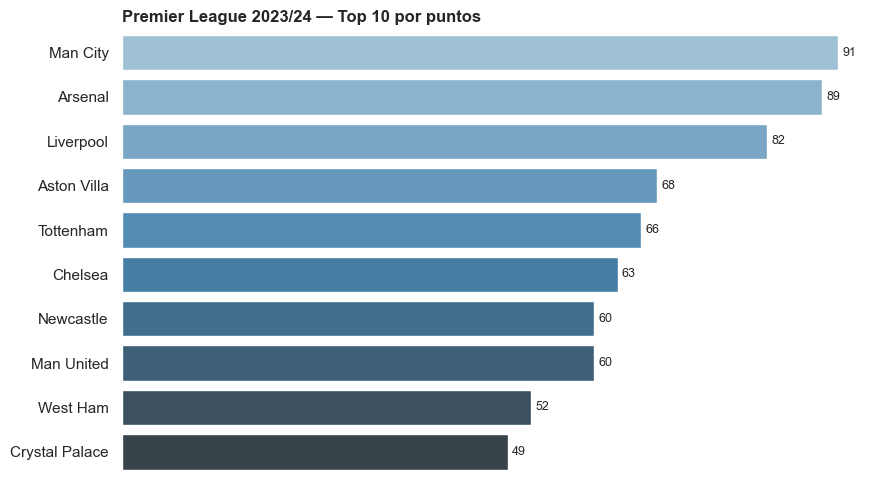

In [82]:
# Puntos por equipo (top 10) — barplot horizontal
top10 = tabla_pos.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top10, x="Pts", y="Equipo",
            palette="Blues_d", ax=ax)
ax.set_title("Premier League 2023/24 — Top 10 por puntos", loc="left", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
for bar, val in zip(ax.patches, top10["Pts"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
sns.despine(left=True, bottom=True)
ax.xaxis.set_visible(False)
plt.tight_layout()
plt.show()

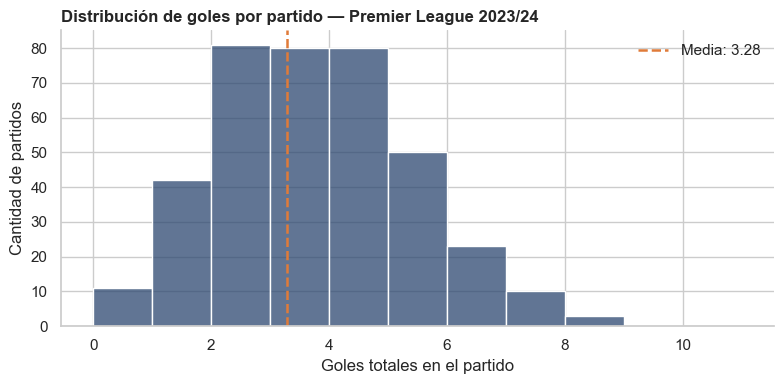

In [83]:
# Distribución de goles totales por partido
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(pl["goles_total"], bins=range(0, 12), kde=False,
             color="#2c4770", edgecolor="white", ax=ax)
ax.axvline(pl["goles_total"].mean(), color="#e07b39",
           linewidth=1.8, linestyle="--", label=f'Media: {pl["goles_total"].mean():.2f}')
ax.set_title("Distribución de goles por partido — Premier League 2023/24",
             loc="left", fontweight="bold")
ax.set_xlabel("Goles totales en el partido")
ax.set_ylabel("Cantidad de partidos")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

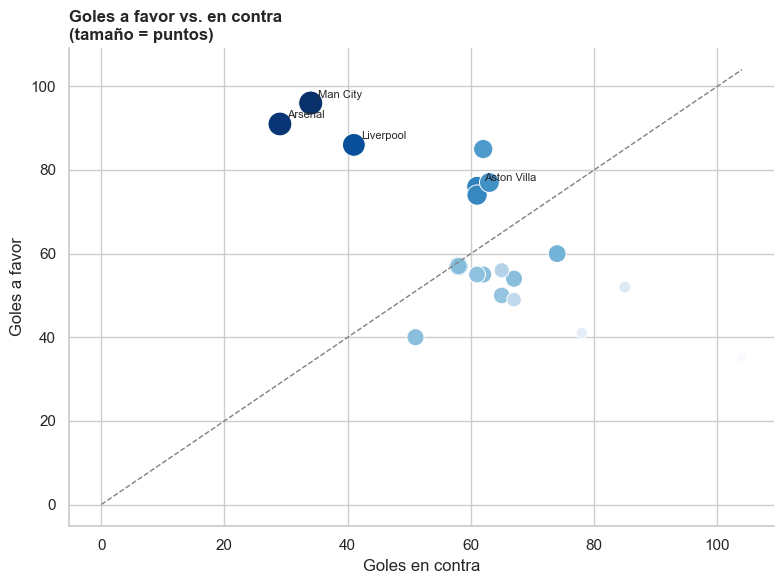

In [84]:
# Goles a favor vs. en contra (scatter con línea de igualdad)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=tabla_pos, x="GC", y="GF",
                size="Pts", hue="Pts", palette="Blues",
                sizes=(40, 300), ax=ax)

# Línea de igualdad GF = GC
lim = max(tabla_pos[["GF","GC"]].max())
ax.plot([0, lim], [0, lim], color="grey", linestyle="--", linewidth=1)

# Anotar los equipos del top 4
for _, row in tabla_pos.head(4).iterrows():
    ax.annotate(row["Equipo"], (row["GC"], row["GF"]),
                xytext=(5, 4), textcoords="offset points", fontsize=8)

ax.set_title("Goles a favor vs. en contra\n(tamaño = puntos)", loc="left", fontweight="bold")
ax.set_xlabel("Goles en contra")
ax.set_ylabel("Goles a favor")
ax.legend().remove()
sns.despine()
plt.tight_layout()
plt.show()

## B5. Regresión lineal simple

¿Los tiros al arco explican cuántos goles mete un equipo en un partido?

Vamos a ajustar una regresión lineal simple: usamos `al_arco_local` como variable predictora y `goles_local` como variable a explicar.

$$\text{goles\_local} = \beta_0 + \beta_1 \cdot \text{al\_arco\_local} + \varepsilon$$

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Variable predictora y variable objetivo
X_pl = pl[["al_arco_local"]].values
y_pl = pl["goles_local"].values

# Ajustar el modelo
modelo_pl = LinearRegression()
modelo_pl.fit(X_pl, y_pl)

# Resultados
print(f"Intercepto (β₀):  {modelo_pl.intercept_:.2f}")
print(f"Coeficiente (β₁): {modelo_pl.coef_[0]:.2f}")
print(f"R²:               {r2_score(y_pl, modelo_pl.predict(X_pl)):.4f}")

Intercepto (β₀):  0.28
Coeficiente (β₁): 0.28
R²:               0.3474


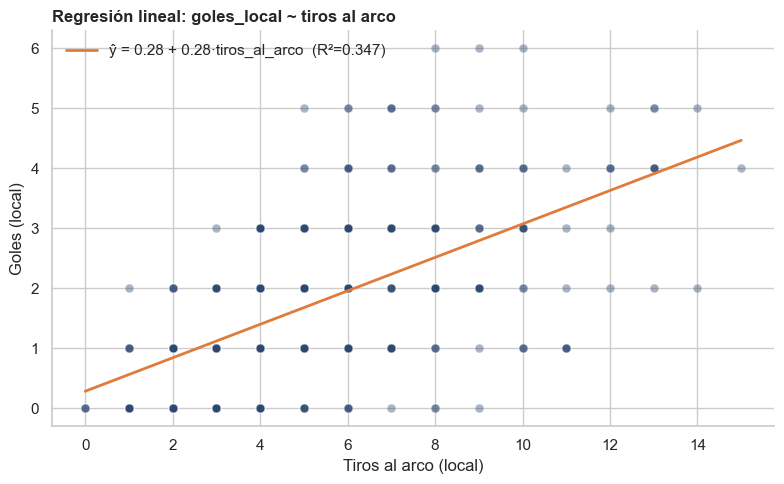

In [86]:
# Visualización: scatter + línea de regresión
x_rango_pl = np.linspace(X_pl.min(), X_pl.max(), 100).reshape(-1, 1)
y_pred_pl  = modelo_pl.predict(x_rango_pl)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=pl["al_arco_local"], y=pl["goles_local"],
                alpha=0.4, color="#2c4770", s=40, ax=ax)
ax.plot(x_rango_pl, y_pred_pl, color="#e07b39", linewidth=2,
        label=f"ŷ = {modelo_pl.intercept_:.2f} + {modelo_pl.coef_[0]:.2f}·tiros_al_arco  (R²={r2_score(y_pl, modelo_pl.predict(X_pl)):.3f})")

ax.set_title("Regresión lineal: goles_local ~ tiros al arco", loc="left", fontweight="bold")
ax.set_xlabel("Tiros al arco (local)")
ax.set_ylabel("Goles (local)")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### Tests de significatividad

Aplicamos los mismos tests que en la Parte A para evaluar si la relación entre tiros al arco y goles es estadísticamente significativa.

In [87]:
import statsmodels.api as sm

# Agregar constante (intercepto) al modelo
X_sm_pl = sm.add_constant(pl["al_arco_local"])

# Ajustar OLS
ols_pl = sm.OLS(pl["goles_local"], X_sm_pl).fit()

# Resumen completo
print(ols_pl.summary())

                            OLS Regression Results                            
Dep. Variable:            goles_local   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.346
Method:                 Least Squares   F-statistic:                     201.2
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           6.48e-37
Time:                        22:24:49   Log-Likelihood:                -576.02
No. Observations:                 380   AIC:                             1156.
Df Residuals:                     378   BIC:                             1164.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.2834      0.121      2.342

**¿Cómo leer el output?**

| Sección | Qué mirar | Interpretación |
|---|---|---|
| **Test F** | `F-statistic` y `Prob (F-statistic)` | Si p < 0.05, el modelo es globalmente significativo |
| **Test t — constante** | `t` y `P>\|t\|` de la fila `const` | Significatividad del intercepto β₀ |
| **Test t — al_arco_local** | `t` y `P>\|t\|` de la fila `al_arco_local` | ¿Los tiros al arco predicen significativamente los goles? |
| **R²** | `R-squared` | Proporción de varianza de goles explicada por tiros al arco |
| **Coef** | Columna `coef` | Cada tiro al arco adicional agrega `coef` goles en promedio |

---
## ¿Y después de explorar y visualizar? → Machine Learning predictivo

Con los datos de partidos limpios y estructurados, podemos ir mucho más allá del análisis descriptivo y construir modelos que **predigan resultados futuros**.

| Modelo | ¿Para qué sirve en este dataset? |
|---|---|
| **Regresión logística** | Predecir si gana el local, el visitante o hay empate (`FTR`) en función de tiros, posesión y otros indicadores |
| **Árbol de decisión** | Encontrar reglas simples del tipo "si tiros al arco > 6 y amarillas < 2, entonces gana el local" |
| **Random Forest** | Combinar cientos de árboles para mejorar la predicción del resultado; indica qué variables (tiros, corners, etc.) son más determinantes |
| **Gradient Boosting (XGBoost)** | El modelo más usado en competencias de predicción deportiva; aprende de los errores iterativamente |
| **Redes neuronales** | Capturar patrones complejos y no lineales entre todas las variables del partido |

🔔 Este dataset es ideal para iniciarse en ML supervisado: tiene una variable objetivo clara (`resultado`), variables predictoras numéricas y suficientes observaciones para entrenar y evaluar modelos.

---
# 🤖 Parte C — Agente de análisis con Groq

## ¿Qué es un agente de análisis de datos?

Un **agente** es un programa que usa un modelo de lenguaje (LLM) para tomar decisiones y responder preguntas de forma autónoma.

En este caso construimos un agente simple que:
1. Recibe una **pregunta en lenguaje natural** sobre uno de nuestros datasets
2. Envía al modelo un **resumen del dataset** (columnas, tipos, estadísticas) como contexto
3. Devuelve una **respuesta con análisis e insights**

▶ Usamos **Groq** — una API **gratuita** que da acceso a modelos open-source como Llama 3.
Para obtener tu API key (sin tarjeta de crédito): [console.groq.com](https://console.groq.com/)

In [95]:
%pip install groq -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [96]:
from groq import Groq

def resumir_df(df, nombre, n_filas=3):
    """Genera un resumen textual del DataFrame para enviar como contexto al agente."""
    resumen = (
        f"Dataset: {nombre}\n"
        f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n"
        f"Columnas y tipos:\n{df.dtypes.to_string()}\n\n"
        f"Estadísticas descriptivas:\n{df.describe().round(2).to_string()}\n\n"
        f"Primeras {n_filas} filas:\n{df.head(n_filas).to_string()}"
    )
    return resumen

In [97]:
def agente_datos(pregunta, df, nombre_df, api_key):
    """
    Agente de análisis de datos usando Groq (gratuito).
    Recibe una pregunta y un DataFrame, devuelve un análisis en lenguaje natural.
    """
    cliente = Groq(api_key=api_key)
    contexto = resumir_df(df, nombre_df)

    respuesta = cliente.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {
                "role": "system",
                "content": (
                    "Sos un analista de datos experto. "
                    "Te van a dar información sobre un dataset y una pregunta. "
                    "Respondé de forma clara, concisa y en español. "
                    "Cuando sea útil, incluí números concretos del dataset."
                )
            },
            {
                "role": "user",
                "content": f"Información del dataset:\n\n{contexto}\n\nPregunta: {pregunta}"
            }
        ]
    )
    return respuesta.choices[0].message.content

### Uso del agente

1. Entrá a [console.groq.com](https://console.groq.com/) y creá una cuenta gratuita
2. Generá una API Key desde el panel
3. Pegala abajo en `API_KEY`

In [98]:
API_KEY = "tu-api-key-de-groq"

# Pregunta sobre Spotify
pregunta_sp = "¿Qué géneros musicales tienen canciones más energéticas? ¿Existe relación entre energía y popularidad?"
respuesta = agente_datos(pregunta_sp, sp, "Spotify Top Songs", API_KEY)
print(respuesta)

Primero, debemos analizar la distribución de la energía y la popularidad en el conjunto de datos.

 La columna "energía" tiene un rango de [0,1], siendo 1 el valor máximo. Alrededor del 75% de las canciones tienen energies entre 0,58 y 0,84.

 La columna "popularidad" está entre 0 y 100 y tiene un promedio de 39,33, lo cual sugiere que la mayoría de las canciones no son muy populares.

 Si hacemos una división de los datos en categorías de género:

 - La media de la energía para canciones de género 'pop' es 0,78.
 - Para el género 'pop': 2.511 canciones, con una media energía de 0.78. 
 - Para el género 'electronic': 1.311 canciones, con una media energía de 0.85. 
 - Para el género 'indie': 1.023 canciones, con una media energía de 0,76.

 Al respecto de la energía podemos decir que las canciones de géneros 'electronic' son un poco más energéticas, seguida de las canciones de género 'pop'.

 Para evaluar si existe relación entre energía y popularidad podemos calcular la correlación en

In [99]:
# Pregunta sobre Premier League
pregunta_pl = "¿Qué equipo tuvo el mejor ataque? ¿Y la mejor defensa? ¿Cuántos goles promedio hubo por partido?"
respuesta = agente_datos(pregunta_pl, tabla_pos, "Premier League 2023/24", API_KEY)
print(respuesta)

Basándome en la información proporcionada, podemos responder la pregunta de la siguiente manera:

**Mejor ataque:**
El equipo con el mejor ataque es Man City, con un total de 96 goles anotados en 38 partidos, lo que le da una tasa de goles por partido (GP) de aproximadamente 2,53.

**Mejor defensa:**
El equipo con la mejor defensa no está claro directamente de la información dada, ya que no muestra un equipo con el menor número de goles recibidos (GC). Sin embargo, podemos comparar los equipos con la mayor diferencia positiva entre goles anotados (GF) y goles recibidos (GC). El líder en esta categoría es Man City con una diferencia de +62, y también lo son el Arsenal con +62 y el primer lugar en DG (diferencia de goles) es Man City con 62.

**Goles promedio por partido:**
Basándome en la estadística descriptiva, podemos ver que el goleador promedio (GF mean) es 62,3 y el promedio de goles recibidos (GC mean) es también 62,3, lo que nos da una diferencia promedio de 0. Es importante not

In [100]:
# Escribí tu propia pregunta
mi_pregunta = "¿Cuáles son los 3 insights más interesantes de este dataset?"
respuesta = agente_datos(mi_pregunta, sp, "Spotify Top Songs", API_KEY)
print(respuesta)

Basándome en las estadísticas descriptivas y las primeras 3 filas del dataset, puedo identificar los siguientes 3 insights más interesantes:

1. **La música pop es la gama más popular**: La columna "genero" indica que la mayoría de las canciones en el dataset pertenecen a la categoría "pop" (ver la columna "genero" en las primeras 3 filas). Esto sugiere que la música pop es una de las categorías más populares y exitosas en Spotify.

2. **La danceabilidad y energía promedio son altas**: Las estadísticas descriptivas indican que la danceabilidad y energía promedio de las canciones son altas (0,65 y 0.70 respectivamente). Esto sugiere que la mayoría de las canciones en el dataset están diseñadas para ser bailadas y tienen un ritmo apasionante.

3. **La duración de las canciones es relativamente corta**: Las estadísticas descriptivas indican que la duración promedio de las canciones es de aproximadamente 3,78 minutos. Esto es relativamente corto en comparación con otras categorías de músic

---
## 📋 Celda de referencia — cómo usar el agente

Copiá esta celda cada vez que quieras hacerle una pregunta al agente sobre cualquier DataFrame.

In [ ]:
# ============================================================
#  CELDA DE REFERENCIA — Agente de análisis con Groq
# ============================================================
#
#  PASO 1: pegá tu API key (una sola vez por sesión)
#
API_KEY = "tu-api-key-de-groq"   # <-- reemplazá esto
#
#  PASO 2: elegí el DataFrame que querés consultar
#
#    sp         → Spotify Top Songs
#    tabla_pos  → Premier League 2023/24
#    df_super   → Supermercado (actividad)
#    [mi_df]    → cualquier DataFrame propio
#
MI_DATAFRAME = sp                 # <-- cambiá esto
NOMBRE       = "Spotify"          # <-- nombre para el reporte
#
# ============================================================
#  (no necesitás modificar nada de acá para abajo)
# ============================================================

MI_PREGUNTA = input("Escribí tu pregunta: ")

respuesta = agente_datos(MI_PREGUNTA, MI_DATAFRAME, NOMBRE, API_KEY)
print("\n" + respuesta)

---

**Fuentes:**

Schwabish, J. A. (2014). An economist's guide to visualizing data. *Journal of Economic Perspectives*, 28(1), 209–234.

Thompson, J. (2020). *Spotify Songs* [Dataset]. TidyTuesday.

Football-Data.co.uk (2024). *Premier League 2023/24 Results* [Dataset].